In [3]:
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [4]:
df = pd.read_csv('housing.csv')

In [5]:
df = pd.get_dummies(df)

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [7]:
df['median_house_value'].mean()

np.float64(206855.81690891474)

In [8]:
df.isna().sum()

longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
ocean_proximity_<1H OCEAN       0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
class HousingData(Dataset):
    def __init__(self, df, scaler, is_test_data, transforms=None):
        self.transforms = transforms
        self.scaler = scaler
        self.df = df
        self.is_test_data = is_test_data

        self.y = self.df[['median_house_value']]
        self.x = self.df.drop('median_house_value', axis=1)

        if self.is_test_data == False:
            self.x = self.scaler.fit_transform(self.x)
        else:
            self.x = self.scaler.transform(self.x)

        self.x = torch.FloatTensor(self.x)
        self.y = torch.FloatTensor(self.y.to_numpy())

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        sample, target = self.x[idx], self.y[idx]
        return sample, target

In [12]:
scaler = StandardScaler()
num_batches = 64

n = len(df)
perc = int(n * 0.8)
df_train = df.head(perc)
df_test = df.tail(n - perc)

train_df = HousingData(df=df_train, scaler=scaler, is_test_data=False)
test_df = HousingData(df=df_test, scaler=scaler, is_test_data=True)

train_dl = DataLoader(train_df, batch_size=num_batches)
test_dl = DataLoader(test_df, batch_size=num_batches)

train_dl.batch_size, test_dl.batch_size

(64, 64)

In [13]:
len(train_dl), len(test_dl)

(256, 64)

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [15]:
class Neuro(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(13, 1024)
        self.linear2 = nn.Linear(1024, 512)
        self.linear3 = nn.Linear(512, 128)
        self.linear4 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.linear3(x)
        x = self.act(x)
        x = self.dropout(x)
        out = self.linear4(x)
        return out


In [16]:
model = Neuro()
model

Neuro(
  (linear1): Linear(in_features=13, out_features=1024, bias=True)
  (linear2): Linear(in_features=1024, out_features=512, bias=True)
  (linear3): Linear(in_features=512, out_features=128, bias=True)
  (linear4): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (act): ReLU()
)

Эпоха 1/30: 100%|██████████| 256/256 [00:03<00:00, 72.99it/s]


Train - 139832.35664367676, Test - 96951.13455200195


Эпоха 2/30: 100%|██████████| 256/256 [00:02<00:00, 94.32it/s]


Train - 66189.49353790283, Test - 64132.60870361328


Эпоха 3/30: 100%|██████████| 256/256 [00:02<00:00, 91.12it/s]


...

Train - 47804.874588012695, Test - 46165.41226196289


Эпоха 29/30: 100%|██████████| 256/256 [00:02<00:00, 106.62it/s]


Train - 47883.45365905762, Test - 45896.34994506836


Эпоха 30/30: 100%|██████████| 256/256 [00:02<00:00, 110.55it/s]


Train - 48122.42998504639, Test - 46072.05520629883


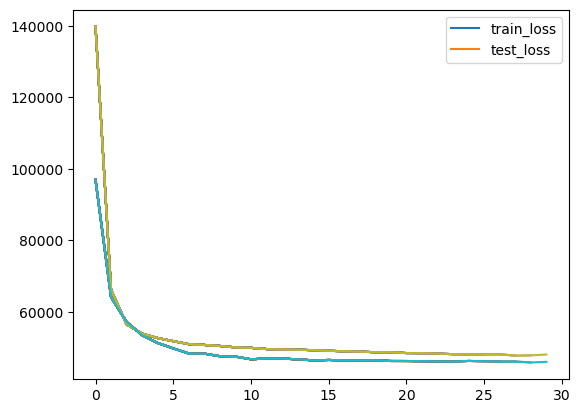

In [17]:
EPOCHS = 30
def train(model, train_data, test_data, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lf = nn.L1Loss(reduction='mean')

    total_train_loss = []
    total_test_loss = []

    plt.ion()

    for epoch in range(EPOCHS):
        train_loss = []
        test_loss = []

        model.train()
        train_loop = tqdm(train_data, desc=f"Эпоха {epoch + 1}/{EPOCHS}")
        for i, (x, y) in enumerate(train_loop):
            x = x.to(device)
            y = y.to(device)

            preds = model(x)
            loss = lf(preds, y)
            train_loss.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        for i, (x, y) in enumerate(test_data):
            x = x.to(device)
            y = y.to(device)

            preds = model(x)
            loss = lf(preds, y)
            test_loss.append(loss.item())
        tqdm.write(f"Train - {sum(train_loss) / len(train_loss)}, Test - {sum(test_loss) / len(test_loss)}")

        total_test_loss.append(sum(test_loss) / len(test_loss))
        total_train_loss.append(sum(train_loss) / len(train_loss))

        plt.plot(total_train_loss)
        plt.plot(total_test_loss)
        plt.legend(['train_loss', 'test_loss'])

plt.ioff()
plt.show()

train(model, train_data=train_dl, test_data=test_dl)